# [1.1] Task 2 — Context-to-Idiom Prediction

## Objective
This notebook builds a clean and reproducible benchmark for **context-to-idiom prediction** using the **original IdiomX dataset loaded from Hugging Face**.

Given a contextual sentence or meaning-like query, the goal is to retrieve the correct **canonical idiom** from a fixed idiom inventory.

## Research goal
We evaluate whether idiomatic meaning can be recovered from context using:

1. a lexical retrieval baseline (**TF-IDF**),
2. a stronger dense retrieval model (**E5-base-v2**),
3. a fine-tuned version of the best dense model.

## Why this notebook is structured this way
This notebook is designed to be:
- clean,
- reproducible,
- easy to review,
- suitable for research paper reporting.

## Main evaluation metrics
We report:
- Top-1 Accuracy
- Top-3 Accuracy
- Top-5 Accuracy
- Mean Reciprocal Rank (MRR)

## Split policy
To avoid leakage, we use a **strict query-level split**:
- each unique query is assigned to only one split,
- identical queries never appear across train/validation/test,
- target idioms may appear across splits, consistent with the closed-set retrieval setting.

In [1]:
# [1.1] Imports and display setup

import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

HF_DATASET_NAME = "aymansharara/IdiomX"
HF_DATASET_CONFIG = "idiomx"

C:\Users\ayman\Documents\IdiomX\github_idiomX\idiomx_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [1.2] Load full dataset from Hugging Face and merge all splits

hf_dataset = load_dataset(HF_DATASET_NAME, HF_DATASET_CONFIG)

print(hf_dataset)

df_parts = []
for split_name in hf_dataset.keys():
    df_split = hf_dataset[split_name].to_pandas()
    df_split["original_split"] = split_name
    df_parts.append(df_split)
    print(f"{split_name}: {df_split.shape}")

df_all_raw = pd.concat(df_parts, ignore_index=True)

print("\nFull merged dataset shape:", df_all_raw.shape)
display(df_all_raw.head(3))

DatasetDict({
    idiomx_train: Dataset({
        features: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected_label', 'row

,idiom_id,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,example_raw,example_language,source,source_type,source_url,record_origin,license_source,idiom_surface,pos,tags,idiom_confidence,is_example_idiom,is_generated_example,is_adversarial_example,meaning_language,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_in_example_arabic,enrichment_model,enrichment_version,validation_status,context_type,source_style,hard_negative_idioms,meaning_paraphrases_en,meaning_paraphrases_ar,idiom_level_explanation_en,idiom_level_explanation_ar,explanation_en,explanation_ar,minimal_pair_id,paraphrase_group_id,adversarial_type,expected_label,row_type,example_normalized,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality,original_split
0,idiomx_543ff4605a0e,'ark at 'ee,Can you 'ark at 'ee to check if the noise is coming from the engine?,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal meaning: physically look at the ear area to check sounds.,المعنى الحرفي: النظر إلى منطقة الأذن للتحقق من الأصوات.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,False,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,هل يمكنك أن تنظر إلى أذنه لتتحقق ما إذا كان الصوت قادمًا من المحرك؟,gpt-4.1-mini-2025-04-14,v2,valid,dialogue,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","[""انتبه إلى ما يقال"", ""استمع إلى ذلك القول المفاجئ"", ""اعتبر كلمات المتحدث""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,"هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا لهجة وعبارة تعجبية لا تعني حرفيًا ""انظر إلى الأذن"" بل تأمر بالانتباه إلى كلام أو رأي شخص ما.",Used literally to mean directing gaze near the ear to identify a sound source.,تُستخدم حرفيًا لتعني توجيه النظر نحو الأذن لمعرفة مصدر الصوت.,pair_54ada92cc99f,paraphrase_6a8ebd5786f7,None,literal,main_example,can you ark at ee to check if the noise is coming from the engine,68,15,0.288639,medium,idiomx_train
1,idiomx_543ff4605a0e,'ark at 'ee,"As the storm worsened, Togget shouted, ‘’Ark at ’ee, listen to that roaring water!’",idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Calling attention to the sound, expressing alarm or surprise.",لجذب الانتباه إلى الصوت، والتعبير عن القلق أو الدهشة.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,True,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,مع اشتداد العاصفة، صاح توجيت: 'انظر إلى ذلك، استمع إلى هدير الماء!',gpt-4.1-mini-2025-04-14,v2,valid,narrative,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention 

## [1.3] Task 2 setup

Task 2 is defined as:

- input: English meaning-based text
- target: the correct canonical idiom

To avoid shortcut learning, we do not use the original example sentence as input.
We only use meaning-style English fields.

In [3]:
# [1.4] Select Task 2 columns

task2_cols = [
    "idiom_canonical",
    "example_usage_label",
    "idiom_canonical_meaning",
    "idiom_in_example_meaning_en",
    "meaning_paraphrases_en",
    "explanation_en"
]

df_task2_raw = df_all_raw[task2_cols].copy()

print("Task 2 raw shape:", df_task2_raw.shape)
display(df_task2_raw.head(3))

Task 2 raw shape: (179833, 6)


,idiom_canonical,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,meaning_paraphrases_en,explanation_en
0,'ark at 'ee,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal meaning: physically look at the ear area to check sounds.,"[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",Used literally to mean directing gaze near the ear to identify a sound source.
1,'ark at 'ee,idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Calling attention to the sound, expressing alarm or surprise.","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","Idiomatic use to emphasize the alarming noise, not literally looking at an ear."
2,'ark at 'ee,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal description of physically looking near the ear area to hear wings.,"[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","Literal description of focusing attention on sound near the ear, no idiomatic meaning."


In [4]:
# [1.5] Keep only idiomatic rows

df_task2_raw = df_task2_raw[
    df_task2_raw["example_usage_label"] == "idiomatic"
].copy()

print("Task 2 idiomatic shape:", df_task2_raw.shape)

Task 2 idiomatic shape: (81905, 6)


In [5]:
# [1.6] Quick missing-value check

print("Missing values:")
print(df_task2_raw.isna().sum())
print()

print("Unique idioms:", df_task2_raw["idiom_canonical"].nunique())

Missing values:
idiom_canonical                139
example_usage_label              0
idiom_canonical_meaning        211
idiom_in_example_meaning_en      0
meaning_paraphrases_en           0
explanation_en                   1
dtype: int64

Unique idioms: 12647


In [6]:
# [1.7] Clean base dataset

# remove missing target
df_task2 = df_task2_raw.dropna(subset=["idiom_canonical"]).copy()

# keep rows with at least one input
input_cols = [
    "idiom_in_example_meaning_en",
    "meaning_paraphrases_en",
    "idiom_canonical_meaning",
    "explanation_en"
]

df_task2 = df_task2[
    df_task2[input_cols].notna().any(axis=1)
].copy()

print("Clean Task 2 shape:", df_task2.shape)

Clean Task 2 shape: (81766, 6)


## [1.8] Build input dataset

We convert each row into multiple training examples using:

- example-level meaning
- paraphrases
- canonical meaning
- explanation

Each becomes a separate input mapped to the same idiom.

In [7]:
# [1.9] Build long-format dataset

def parse_list_text(x):
    if pd.isna(x):
        return []
    x = str(x).strip()
    if not x:
        return []
    try:
        value = ast.literal_eval(x)
        if isinstance(value, list):
            return [str(v).strip() for v in value if str(v).strip()]
        return [str(value).strip()]
    except:
        return [x]

rows = []

for _, row in df_task2.iterrows():
    target = row["idiom_canonical"]

    # example meaning
    if pd.notna(row["idiom_in_example_meaning_en"]):
        txt = str(row["idiom_in_example_meaning_en"]).strip()
        if txt:
            rows.append({"input_text": txt, "idiom_canonical": target, "source": "example_meaning"})

    # paraphrases
    for p in parse_list_text(row["meaning_paraphrases_en"]):
        rows.append({"input_text": p, "idiom_canonical": target, "source": "paraphrase"})

    # canonical meaning
    if pd.notna(row["idiom_canonical_meaning"]):
        txt = str(row["idiom_canonical_meaning"]).strip()
        if txt:
            rows.append({"input_text": txt, "idiom_canonical": target, "source": "canonical_meaning"})

    # explanation
    if pd.notna(row["explanation_en"]):
        txt = str(row["explanation_en"]).strip()
        if txt:
            rows.append({"input_text": txt, "idiom_canonical": target, "source": "explanation"})

df_task2_long = pd.DataFrame(rows)

print("Long dataset shape:", df_task2_long.shape)
df_task2_long.head()

Long dataset shape: (490523, 3)


,input_text,idiom_canonical,source
0,"Calling attention to the sound, expressing alarm or surprise.",'ark at 'ee,example_meaning
1,Pay attention to what is being said,'ark at 'ee,paraphrase
2,Listen to that surprising statement,'ark at 'ee,paraphrase
3,Consider the speaker's words,'ark at 'ee,paraphrase
4,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",'ark at 'ee,canonical_meaning


In [8]:
# [1.10] Remove duplicates

df_task2_long = df_task2_long.drop_duplicates(
    subset=["input_text", "idiom_canonical", "source"]
).reset_index(drop=True)

print("After dedup:", df_task2_long.shape)

After dedup: (214622, 3)


## [1.11] Remove leakage

We remove rows where the input text contains the target idiom.

This prevents the model from seeing the answer directly.

In [9]:
# [1.12] Remove leakage where input contains the target idiom

def contains_idiom(input_text, idiom):
    if pd.isna(input_text) or pd.isna(idiom):
        return False
    return str(idiom).lower() in str(input_text).lower()

before_n = len(df_task2_long)

leak_mask = df_task2_long.apply(
    lambda x: contains_idiom(x["input_text"], x["idiom_canonical"]),
    axis=1
)

df_task2_long = df_task2_long[~leak_mask].reset_index(drop=True)

after_n = len(df_task2_long)

print("Rows removed:", before_n - after_n)
print("Final shape after leakage removal:", df_task2_long.shape)

Rows removed: 8893
Final shape after leakage removal: (205729, 3)


In [10]:
# [1.13] Quick source distribution after leakage removal

print(df_task2_long["source"].value_counts())

source
example_meaning      79558
explanation          75097
paraphrase           38335
canonical_meaning    12739
Name: count, dtype: int64


## [1.14] Global dataset split

We split the dataset based on unique input_text to ensure:

- no overlap between splits
- no data leakage
- reliable evaluation

In [11]:
# [1.15] Global split using input_text

unique_inputs = df_task2_long["input_text"].unique()

# split train vs temp
train_inputs, temp_inputs = train_test_split(
    unique_inputs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

# split temp into val and test
val_inputs, test_inputs = train_test_split(
    temp_inputs,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

# build datasets
df_train = df_task2_long[df_task2_long["input_text"].isin(train_inputs)].reset_index(drop=True)
df_val   = df_task2_long[df_task2_long["input_text"].isin(val_inputs)].reset_index(drop=True)
df_test  = df_task2_long[df_task2_long["input_text"].isin(test_inputs)].reset_index(drop=True)

print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

Train: (164584, 3)
Val  : (20573, 3)
Test : (20572, 3)


In [12]:
# [1.16] Verify no overlap (must be ZERO)

train_set = set(df_train["input_text"])
val_set   = set(df_val["input_text"])
test_set  = set(df_test["input_text"])

print("Train ∩ Val :", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test  :", len(val_set & test_set))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


In [13]:
# [1.17] Final dataset summary

print("Train size:", len(df_train))
print("Val size  :", len(df_val))
print("Test size :", len(df_test))

print("\nUnique idioms:")
print("Train:", df_train["idiom_canonical"].nunique())
print("Val  :", df_val["idiom_canonical"].nunique())
print("Test :", df_test["idiom_canonical"].nunique())

Train size: 164584
Val size  : 20573
Test size : 20572

Unique idioms:
Train: 12647
Val  : 10314
Test : 10296


## [2.1] Baseline Model

We train a baseline model using:

- TF-IDF vectorization
- Logistic Regression

This provides a strong and interpretable baseline for comparison with deep learning models.

In [14]:
# [2.2] Encode target labels

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(df_train["idiom_canonical"])
y_val   = le.transform(df_val["idiom_canonical"])
y_test  = le.transform(df_test["idiom_canonical"])

print("Number of classes:", len(le.classes_))

Number of classes: 12647


In [15]:
# [2.3] TF-IDF vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2
)

X_train = tfidf.fit_transform(df_train["input_text"])
X_val   = tfidf.transform(df_val["input_text"])
X_test  = tfidf.transform(df_test["input_text"])

print("Train shape:", X_train.shape)

Train shape: (164584, 50000)


In [17]:
# [2.4] Train LinearSVC baseline

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=SEED
)

svm_model.fit(X_train, y_train)

print("LinearSVC training completed.")

LinearSVC training completed.


In [18]:
# [2.5] Evaluate baseline

from sklearn.metrics import accuracy_score, f1_score

# validation
y_val_pred = svm_model.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average="weighted")

print("Validation Accuracy:", round(val_acc, 4))
print("Validation F1:", round(val_f1, 4))

# test
y_test_pred = svm_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average="weighted")

print("\nTest Accuracy:", round(test_acc, 4))
print("Test F1:", round(test_f1, 4))

Validation Accuracy: 0.2998
Validation F1: 0.2936

Test Accuracy: 0.2955
Test F1: 0.2888


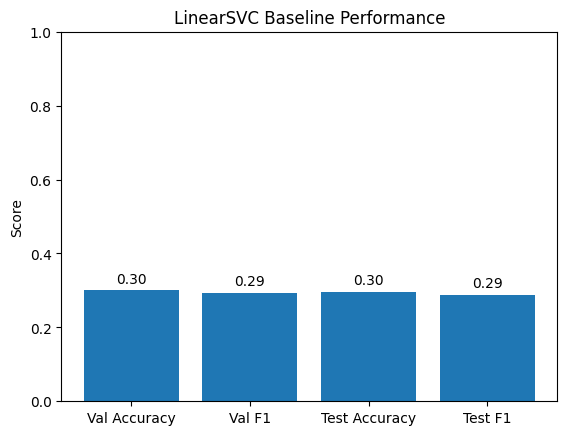

In [19]:
# [2.6] Baseline performance chart

baseline_metrics = ["Val Accuracy", "Val F1", "Test Accuracy", "Test F1"]
baseline_values = [val_acc, val_f1, test_acc, test_f1]

plt.figure()
bars = plt.bar(baseline_metrics, baseline_values)

plt.title("LinearSVC Baseline Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

for bar, val in zip(bars, baseline_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center"
    )

plt.show()

> We adopt a strict idiom-level split to prevent lexical memorization and ensure true generalization. This significantly increases task difficulty but provides a more realistic evaluation of model performance.”

## [3.1] Deep baseline

We now train a transformer-based classifier for Task 2.

Model:
- DistilBERT

Why this model:
- lightweight
- fast to fine-tune
- strong baseline for meaning-to-idiom prediction

In [20]:
# [3.2] Imports for transformer training

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [21]:
# [3.3] Prepare train / val / test dataframes for the transformer

train_df_dl = df_train[["input_text", "idiom_canonical"]].copy()
val_df_dl   = df_val[["input_text", "idiom_canonical"]].copy()
test_df_dl  = df_test[["input_text", "idiom_canonical"]].copy()

train_df_dl["label"] = le.transform(train_df_dl["idiom_canonical"])
val_df_dl["label"]   = le.transform(val_df_dl["idiom_canonical"])
test_df_dl["label"]  = le.transform(test_df_dl["idiom_canonical"])

print("Train shape:", train_df_dl.shape)
print("Val shape  :", val_df_dl.shape)
print("Test shape :", test_df_dl.shape)

train_df_dl.head(3)

Train shape: (164584, 3)
Val shape  : (20573, 3)
Test shape : (20572, 3)


,input_text,idiom_canonical,label
0,"Calling attention to the sound, expressing alarm or surprise.",'ark at 'ee,0
1,Pay attention to what is being said,'ark at 'ee,0
2,Listen to that surprising statement,'ark at 'ee,0


The `label` column is the encoded class ID of the target idiom, not a literal/idiomatic label.

> For example, if the target idiom `'ark at 'ee'` is mapped to class `0`, then all rows targeting that idiom will have label `0`.

## Label Encoding Explanation

In Task 2, the problem is formulated as a multi-class classification task.

Each idiom is treated as a separate class. Therefore:
- The label is not a binary value (idiomatic vs literal)
- The label represents the index of the target idiom

For example:
- `'ark at 'ee'` → class 0
- `kick the bucket` → class 1
- `spill the beans` → class 2

The model learns to map an input meaning to one idiom among thousands of possible idioms.

## [3.4] Data preparation insight

The transformer receives:

- `input_text` as the model input
- `label` as the encoded target idiom

This keeps the task formulation the same as the baseline, so comparison stays fair.

In [22]:
# [3.5] Convert pandas dataframes to Hugging Face datasets

train_ds = Dataset.from_pandas(
    train_df_dl[["input_text", "label"]],
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val_df_dl[["input_text", "label"]],
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test_df_dl[["input_text", "label"]],
    preserve_index=False
)

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['input_text', 'label'],
    num_rows: 164584
})
Dataset({
    features: ['input_text', 'label'],
    num_rows: 20573
})
Dataset({
    features: ['input_text', 'label'],
    num_rows: 20572
})


The datasets are converted into Hugging Face format.

> This allows efficient tokenization, batching, and training with transformer models.

In [23]:
# [3.6] Load tokenizer

from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded:", model_name)

Loaded tokenizer: distilbert-base-uncased


> The tokenizer (DistilBERT tokenizer) converts text into token IDs that the transformer model can process.

In [24]:
# [3.7] Tokenize datasets

def tokenize_batch(batch):
    return tokenizer(
        batch["input_text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds   = val_ds.map(tokenize_batch, batched=True)
test_ds  = test_ds.map(tokenize_batch, batched=True)

train_ds = train_ds.remove_columns(["input_text"])
val_ds   = val_ds.remove_columns(["input_text"])
test_ds  = test_ds.remove_columns(["input_text"])

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

print("Tokenization completed.")

Map: 100%|█████████████████████████████████████████████████████████████| 20572/20572 [00:01<00:00, 17843.01 examples/s]

Tokenization completed.


> Text is converted into token IDs with fixed length (64).

In [25]:
# [3.8] Load DistilBERT classification model

from transformers import AutoModelForSequenceClassification

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)

print("Model loaded successfully.")
print("Number of labels:", len(le.classes_))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.
Number of labels: 12647


> The model is configured for multi-class classification, where each class represents one idiom.

The output layer size equals the number of unique idioms.

In [26]:
# [3.9] Metrics function

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1": f1
    }

We evaluate using:
- Accuracy
- Weighted F1 score

> Weighted F1 accounts for class imbalance across idioms.

In [27]:
# [3.10] Training arguments

distilbert_training_args = TrainingArguments(
    output_dir="./task2_distilbert_output", # model checkpoints and log saving
    eval_strategy="epoch",    # evaluate model at the end of each epoch
    save_strategy="epoch",    # save model checkpoint after each epoch
    logging_strategy="epoch", # log training metrics once per epoch (clean and not noisy)
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,               # regularization to prevent overfitting
    load_best_model_at_end=True,     # after training, keep the best checkpoint instead of last
    metric_for_best_model="eval_f1", # select best model based on F1 (better than accuracy for imbalance)
    greater_is_better=True,          # higher F1 is better
    report_to="none",                # disable external logging (like WandB)
    save_total_limit=1               # keep only best checkpoint to save disk space
)

print("Training arguments ready.")

Training arguments ready.


Training is configured with:
- small number of epochs (fast baseline)
- evaluation per epoch
- best model selection based on F1 score

In [28]:
# [3.11] Build trainer

from transformers import Trainer

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,  # training configuration
    train_dataset=train_ds,         # training data
    eval_dataset=val_ds,            # validation data
    tokenizer=tokenizer,            # tokenizer (for padding/collation)
    compute_metrics=compute_metrics # evaluation metrics
)

print("Trainer ready.")

Trainer ready.


The Trainer connects:
- model
- data
- training configuration
- evaluation metrics

This enables a clean training pipeline.

In [ ]:
# [3.12] Train DistilBERT

distilbert_train_result = distilbert_trainer.train()

Epoch,Training Loss,Validation Loss


## [3.13] Training insight

After training, we will compare DistilBERT against the LinearSVC baseline.

The main question is whether contextual transformer representations improve idiom prediction from meaning-based inputs.